In [1]:
import math
import subprocess
import pynauty as nauty
from collections import Counter

def decode_g6_to_adj(g6_str, n):
    """Fast Graph6 decoder for n < 63."""
    # Skip the first character (node count 'N' for n=14 is 'M')
    data = [ord(c) - 63 for c in g6_str[1:]]
    adj = {i: [] for i in range(n)}
    
    current_byte = 0
    bit_pos = 5
    
    # Graph6 stores the upper triangle of the adjacency matrix
    for j in range(1, n):
        for i in range(j):
            if (data[current_byte] >> bit_pos) & 1:
                adj[i].append(j)
                adj[j].append(i)
            
            bit_pos -= 1
            if bit_pos < 0:
                bit_pos = 5
                current_byte += 1
    return adj

def get_clique_stats(adj, n):
    """Returns (max_clique_size, num_max_cliques)."""
    max_c = 0
    num_c = 0
    
    def bron_kerbosch(r, p, x):
        nonlocal max_c, num_c
        if not p and not x:
            if len(r) > max_c:
                max_c = len(r)
                num_c = 1
            elif len(r) == max_c:
                num_c += 1
            return
        
        if len(r) + len(p) < max_c: # Pruning
            return

        u = max(p | x, key=lambda node: len(set(adj[node]) & p))
        for v in list(p - set(adj[u])):
            bron_kerbosch(r | {v}, p & set(adj[v]), x & set(adj[v]))
            p.remove(v)
            x.add(v)

    bron_kerbosch(set(), set(range(n)), set())
    return max_c, num_c

def get_degeneracy(adj, n):
    """O(m) k-core / degeneracy algorithm."""
    degrees = {u: len(neighbors) for u, neighbors in adj.items()}
    nodes = sorted(degrees.keys(), key=lambda x: degrees[x])
    bin_boundaries = [0] * (n + 1)
    
    # Sort nodes by degree
    curr_deg = 0
    for i, node in enumerate(nodes):
        if degrees[node] > curr_deg:
            for d in range(curr_deg + 1, degrees[node] + 1):
                bin_boundaries[d] = i
            curr_deg = degrees[node]
    
    pos = {node: i for i, node in enumerate(nodes)}
    max_core = 0
    
    for node in nodes:
        max_core = max(max_core, degrees[node])
        for neighbor in adj[node]:
            if degrees[neighbor] > degrees[node]:
                # Move neighbor to the front of its degree bin
                d = degrees[neighbor]
                p = pos[neighbor]
                b = bin_boundaries[d]
                node_at_bin_start = nodes[b]
                
                if neighbor != node_at_bin_start:
                    nodes[p], nodes[b] = nodes[b], nodes[p]
                    pos[neighbor], pos[node_at_bin_start] = pos[node_at_bin_start], pos[neighbor]
                
                bin_boundaries[d] += 1
                degrees[neighbor] -= 1
                
    return max_core

In [7]:
import subprocess
import networkx as nx
import pynauty as nauty
from collections import Counter
import math
import random
from joblib import Parallel, delayed
from tqdm.auto import tqdm 

def process_chunk(n, m, t, chunk_str):
    distribution = Counter()
    n_fact = math.factorial(n)

    cmd = ['geng_tris', str(n), str(m), str(t), chunk_str, '-q', '-X2']
    
    process = subprocess.Popen(
        cmd, 
        stdout=subprocess.PIPE, 
        text=True
    )
    
    for line in process.stdout:
        g6_str = line.strip()
        if not g6_str: continue
        
        adj = decode_g6_to_adj(g6_str, n)
        max_clique, num_max_cliques = get_clique_stats(adj, n)
        degeneracy = get_degeneracy(adj, n)
        
        g_nauty = nauty.Graph(number_of_vertices=n, adjacency_dict=adj)
        res = nauty.autgrp(g_nauty)
        aut_size = int(res[1])
        
        weight = n_fact // aut_size
       
        distribution[(max_clique, num_max_cliques, degeneracy)] += weight

    process.wait()
    print(chunk_str)
    return distribution


if __name__ == '__main__':
    n = 14
    m = 28
    t = 14
    total_chunks = 100000
    num_samples = 100

    sampled_chunk_indices = random.sample(range(total_chunks), num_samples)
    print(f"Sampled chunk indices: {sampled_chunk_indices}")
    chunk_strs = [f"{idx}/{total_chunks}" for idx in sampled_chunk_indices]
    
    print(f"Running {num_samples} chunks out of {total_chunks} in parallel...")
    
    parallel_generator = Parallel(n_jobs=-1, return_as="generator_unordered", batch_size=1)(
        delayed(process_chunk)(n, m, t, chunk_str) 
        for chunk_str in chunk_strs
    )
    
    combined_distribution = Counter()
    for res in tqdm(parallel_generator, total=len(chunk_strs), desc="Processing Chunks"):
        combined_distribution += res
    print("\n--- All chunks completed ---")
    total_in_sample = 0
    
    for (max_clique, num_max_cliques, degeneracy), count in sorted(combined_distribution.items()):
        total_in_sample += count
        print(f"Max Clique: {max_clique}, Num Max Cliques: {num_max_cliques}, Degeneracy: {degeneracy} -> Count: {count}")
    
    print(f"\nTotal weighted graphs in this {num_samples}-chunk sample: {total_in_sample}")
    
    multiplier = total_chunks / num_samples
    estimated_total = total_in_sample * multiplier
    print(f"Estimated total graphs in the full space: {estimated_total:,.0f}")

Sampled chunk indices: [24892, 16085, 65622, 85484, 31888, 21302, 29952, 8438, 25556, 65309, 17254, 57582, 49410, 78394, 96499, 38894, 85554, 58688, 88611, 7275, 55317, 35002, 33386, 71914, 33891, 6247, 55638, 59238, 13826, 24721, 45970, 37559, 57347, 29022, 70380, 88927, 32459, 92144, 41253, 43264, 37022, 70138, 59451, 92071, 32146, 81871, 34178, 61842, 5795, 20478, 97908, 31304, 58571, 33316, 41225, 52554, 9610, 45986, 39731, 71156, 5239, 52509, 27954, 47037, 29542, 74599, 11954, 3996, 98058, 50258, 58050, 33830, 11953, 45015, 93763, 94383, 76878, 43869, 90990, 2591, 42185, 68731, 45923, 90613, 9501, 79743, 32074, 78589, 96124, 55390, 31487, 76482, 66766, 61894, 94132, 18269, 38162, 56748, 57766, 66024]
Running 100 chunks out of 100000 in parallel...


Processing Chunks:   0%|          | 0/100 [00:00<?, ?it/s]

78394/100000
31888/100000
96499/100000
85484/100000
29952/100000
8438/100000
38894/100000
17254/100000
24892/100000
16085/100000
57582/100000
65309/100000
49410/100000
25556/100000
65622/100000
21302/100000
33386/100000
58688/100000
85554/100000
55317/100000
88611/100000
71914/100000
6247/100000
35002/100000
7275/100000
33891/100000
45970/100000
37559/100000
59238/100000
55638/100000
24721/100000
13826/100000
70380/100000
29022/100000
37022/100000
34178/100000
59451/100000
57347/100000
43264/100000
70138/100000
88927/100000
92144/100000
92071/100000
32146/100000
32459/100000
5795/100000
97908/100000
41253/100000
81871/100000
45986/100000
20478/100000
61842/100000
33316/100000
39731/100000
58571/100000
31304/100000
5239/100000
71156/100000
41225/100000
9610/100000
98058/100000
52554/100000
27954/100000
50258/100000
11954/100000
52509/100000
29542/100000
33830/100000
74599/100000
58050/100000
93763/100000


/home/hartd2003/IIB/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


68731/100000
11953/100000
3996/100000
47037/100000
45015/100000
94383/100000
43869/100000
90990/100000
76878/100000
9501/100000
42185/100000
2591/100000
90613/100000
32074/100000
76482/100000
55390/100000
79743/100000
66766/100000
96124/100000
94132/100000
45923/100000
31487/100000
66024/100000
78589/100000
61894/100000
56748/100000
57766/100000
38162/100000
18269/100000

--- All chunks completed ---
Max Clique: 3, Num Max Cliques: 14, Degeneracy: 3 -> Count: 531740700250119360
Max Clique: 3, Num Max Cliques: 14, Degeneracy: 4 -> Count: 122343719090753160
Max Clique: 3, Num Max Cliques: 14, Degeneracy: 5 -> Count: 371869898400
Max Clique: 4, Num Max Cliques: 1, Degeneracy: 3 -> Count: 2447126051859609120
Max Clique: 4, Num Max Cliques: 1, Degeneracy: 4 -> Count: 241411058765997120
Max Clique: 4, Num Max Cliques: 1, Degeneracy: 5 -> Count: 440431992000
Max Clique: 4, Num Max Cliques: 2, Degeneracy: 3 -> Count: 3568941842565939840
Max Clique: 4, Num Max Cliques: 2, Degeneracy: 4 -> Count

In [8]:
#save to pd df
import pandas as pd
df = pd.DataFrame(
    [(max_clique, num_max_cliques, degeneracy, count) for (max_clique, num_max_cliques, degeneracy), count in combined_distribution.items()],
    columns=['Max Clique', 'Num Max Cliques', 'Degeneracy', 'Count']
)
print(df.head())
df.to_csv('graph_distribution_n14_m28_t14.csv', index=False)

   Max Clique  Num Max Cliques  Degeneracy                Count
0           4                4           3    44145717238022400
1           4                2           3  3568941842565939840
2           4                3           3  1222268825859681600
3           3               14           3   531740700250119360
4           4                1           3  2447126051859609120


In [9]:
df1 = pd.read_csv('graph_distribution_n14_m28_t14.csv')
print(df1.head())

   Max Clique  Num Max Cliques  Degeneracy                Count
0           4                4           3    44145717238022400
1           4                2           3  3568941842565939840
2           4                3           3  1222268825859681600
3           3               14           3   531740700250119360
4           4                1           3  2447126051859609120


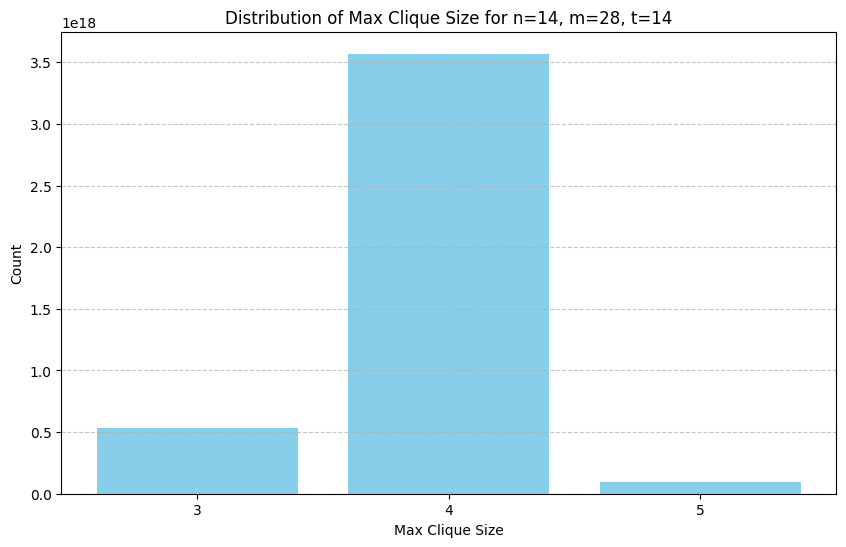

In [10]:
#plot the distribution of max clique size vs count
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(df1['Max Clique'], df1['Count'], color='skyblue')
plt.xlabel('Max Clique Size')
plt.ylabel('Count')
plt.title('Distribution of Max Clique Size for n=14, m=28, t=14')
plt.xticks(range(df1['Max Clique'].min(), df1['Max Clique'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


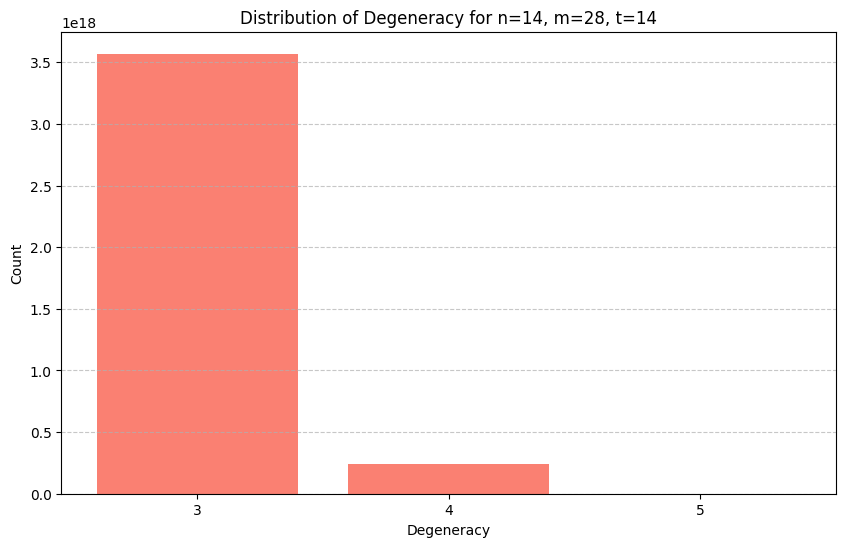

In [11]:
#degeneracy distribution
plt.figure(figsize=(10, 6))
plt.bar(df1['Degeneracy'], df1['Count'], color='salmon')
plt.xlabel('Degeneracy')
plt.ylabel('Count')
plt.title('Distribution of Degeneracy for n=14, m=28, t=14')
plt.xticks(range(df1['Degeneracy'].min(), df1['Degeneracy'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()